In [17]:
import pandas as pd
import os
from arima.utils.utils import EnsembleProjections
from ndc_probability.utils.prob_utils import ProbUtils
from scenario_discovery.utils.utils import ScenarioDiscoveryOptimizer, VulnerabilityAnalyzer

In [18]:
ep = EnsembleProjections()
pu = ProbUtils()
sdo = ScenarioDiscoveryOptimizer()
va = VulnerabilityAnalyzer()

In [19]:
# Set up run id
RUN_ID = 1773188058
SD_OUTPUT_ID = "1773188058_124_20260408_145246"

In [20]:
SCRIPT_DIR_PATH = os.getcwd()
FIGURES_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "paper_figures")
os.makedirs(FIGURES_DIR_PATH, exist_ok=True)

ARIMA_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "arima")
ARIMA_ENSEMBLE_DIR_PATH = os.path.join(ARIMA_DIR_PATH, "output", "ensemble")
ARIMA_POSTPROCESSING_DIR_PATH = os.path.join(ARIMA_DIR_PATH, "output", "postprocessed_ensemble")
HP_FILTERED_DIR_PATH = os.path.join(ARIMA_DIR_PATH, "output", "hp_filtered")

ML_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "ml")
ML_TRAINING_DIR_PATH = os.path.join(ML_DIR_PATH, "output", "training")

PROB_TABLES_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "ndc_probability", "tables")
SD_OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "scenario_discovery", "output", SD_OUTPUT_ID)

### Pull new data to create the figures or use the available one

In [ ]:
from paper_figure_utils.utils import PaperFiguresUtils

tables = PaperFiguresUtils.load_figure_tables(
    run_id=RUN_ID,
    sd_output_id=SD_OUTPUT_ID,
    save_new_data=True,
    save_format="parquet"
)

historical_df = tables["historical_df"]
historical_em_df = tables["historical_em_df"]
postprocessed_ensemble_df = tables["postprocessed_ensemble_df"]
ndc_prob_df = tables["ndc_prob_df"]
top_combinations_df = tables["top_combinations_df"]
future_dist_df_dict = tables["future_dist_df_dict"]
opt_results_df_dict = tables["opt_results_df_dict"]


## Arima Projection Figures

### Emission Predictions

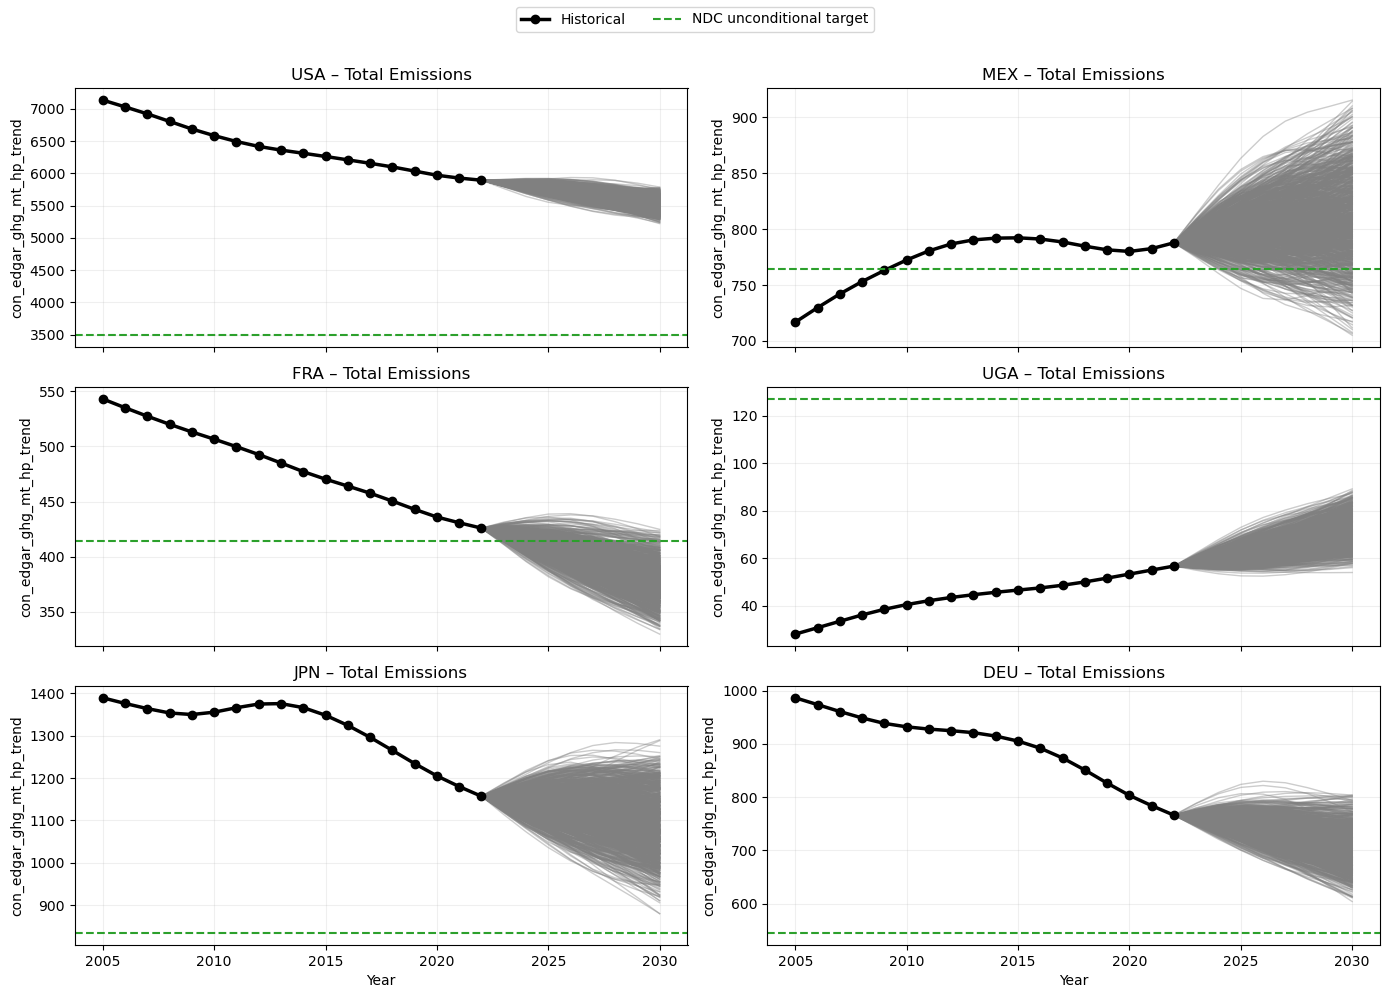

In [22]:
emissions_variable = "con_edgar_ghg_mt_hp_trend"

panels = [
    {"iso": "USA", "column": emissions_variable, "title": "USA – Total Emissions"},
    {"iso": "MEX", "column": emissions_variable, "title": "MEX – Total Emissions"},
    {"iso": "FRA", "column": emissions_variable, "title": "FRA – Total Emissions"},
    {"iso": "UGA", "column": emissions_variable, "title": "UGA – Total Emissions"},
    {"iso": "JPN", "column": emissions_variable, "title": "JPN – Total Emissions"},
    {"iso": "DEU", "column": emissions_variable, "title": "DEU – Total Emissions"},
]

ep.plot_ensemble_time_series_grid(
    df=postprocessed_ensemble_df,
    hist_df=historical_em_df,
    ndc_targets_df=ndc_prob_df,
    ndc_target_display="unconditional",
    panels=panels,
    ncols=2,
    figsize=(14, 10),
    save_path=os.path.join(FIGURES_DIR_PATH, "postprocessed_ensemble_total_emissions_ndc.png")
)

## Probability Analysis

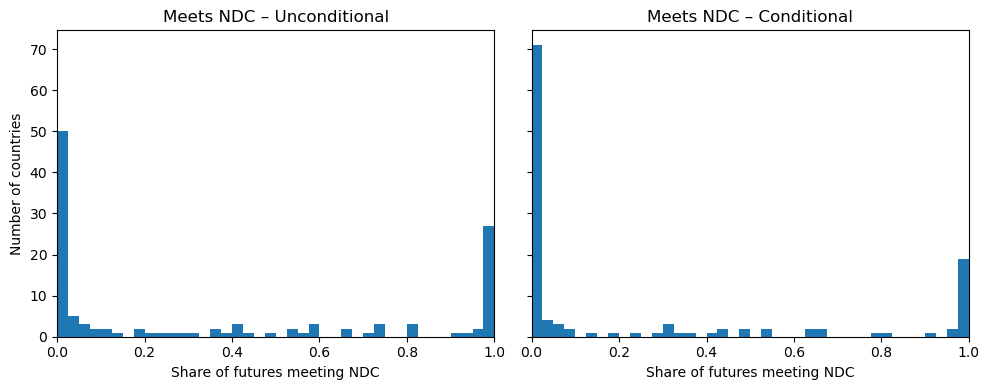

In [23]:
pu.plot_ndc_meets_histograms(
    df=ndc_prob_df,
    bins=40,
    save_path=os.path.join(FIGURES_DIR_PATH, "ndc_meets_histograms.png")
)

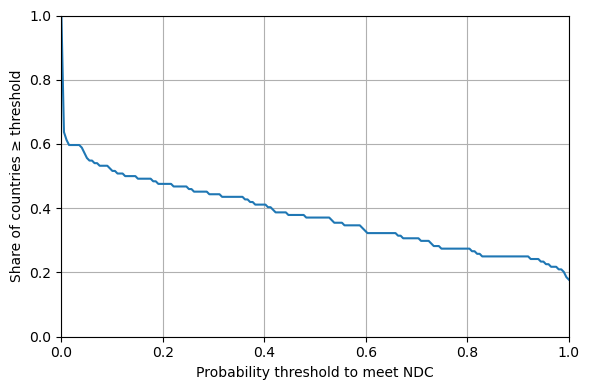

In [24]:
pu.plot_share_countries_above_probability(
    ndc_prob_df,
    prob_col="meets_ndc_unconditional_target",
    save_path=os.path.join(FIGURES_DIR_PATH, "share_countries_above_unconditional_probability.png")
)

In [25]:
total_countries = ndc_prob_df['iso_alpha_3'].nunique()
total_countries_with_prob = ndc_prob_df[ndc_prob_df['meets_ndc_unconditional_target'] > 0.5]['iso_alpha_3'].nunique()

print(f"Number of countries in the analysis: {total_countries}")
print(f"Percentage of countries having > 50% probability of meeting the unconditional target: {(total_countries_with_prob / total_countries * 100):.2f}%")

Number of countries in the analysis: 124
Percentage of countries having > 50% probability of meeting the unconditional target: 37.10%


## Scenario Discovery

### 2030 Emission Distribution

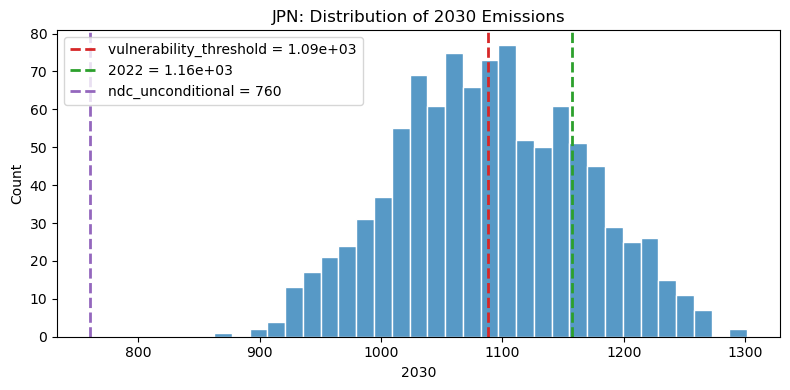

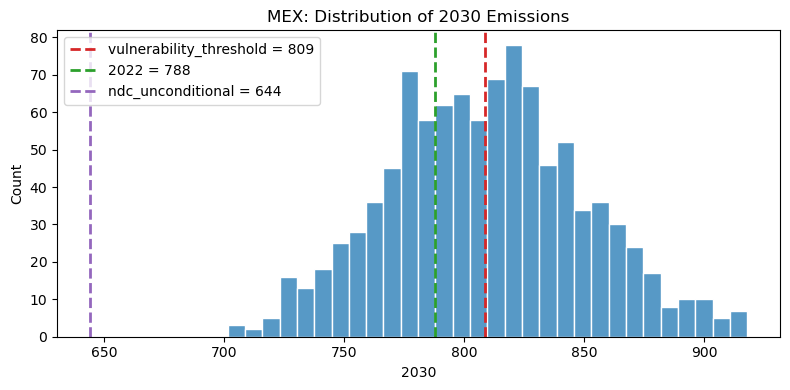

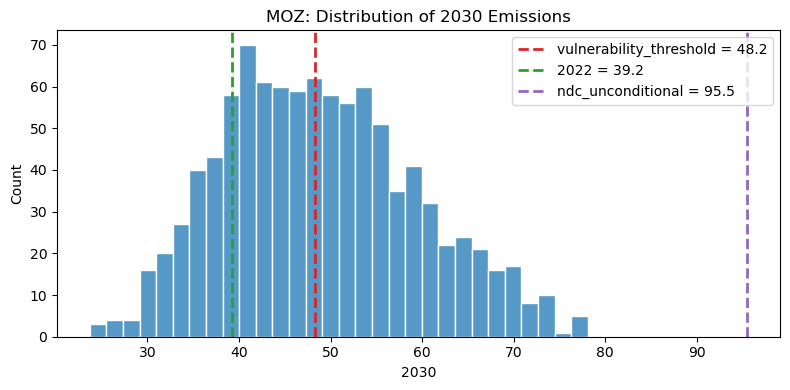

In [26]:
for region, future_dist_df in future_dist_df_dict.items():
    va.plot_future_distribution_with_baseline(
        df_pivot=future_dist_df,
        future_col="2030",
        baseline_col="vulnerability_threshold",
        title=f"{region}: Distribution of 2030 Emissions",
        save_path=os.path.join(FIGURES_DIR_PATH, f"{region.lower()}_distribution_2030_emissions.png")
    )

### Pareto Front

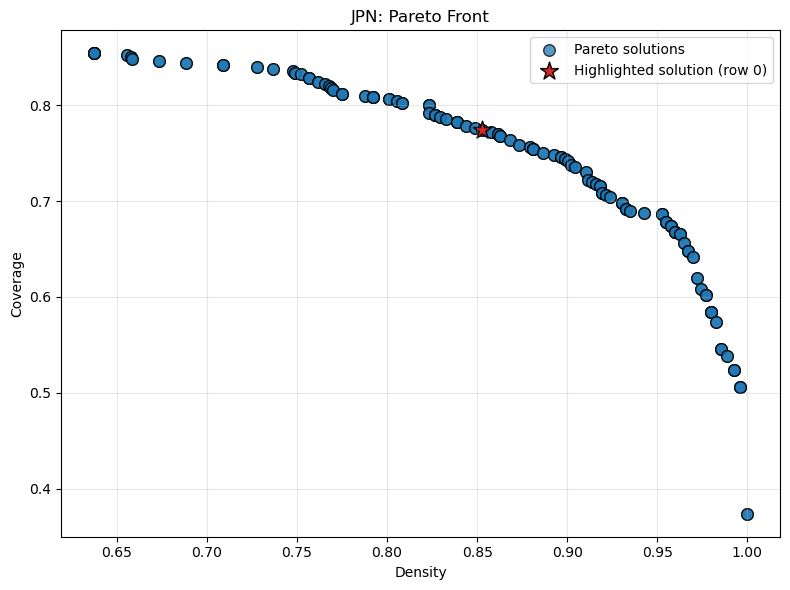

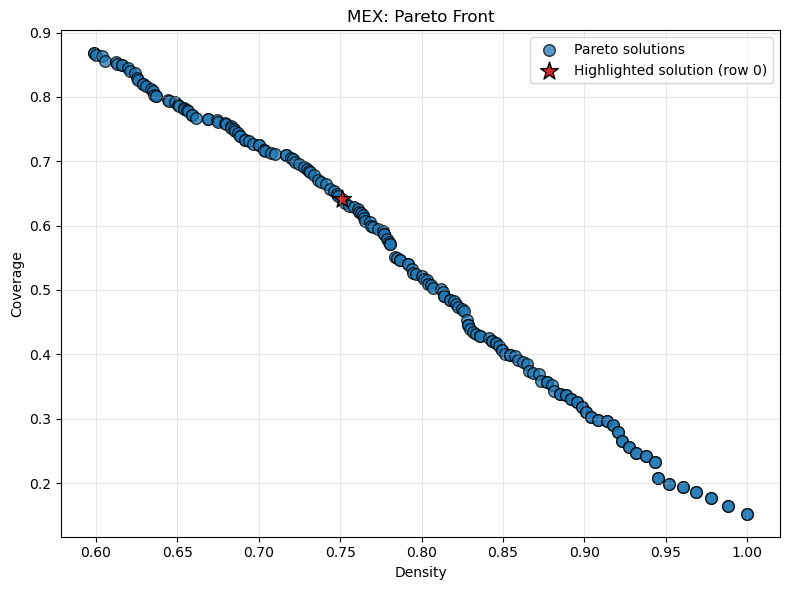

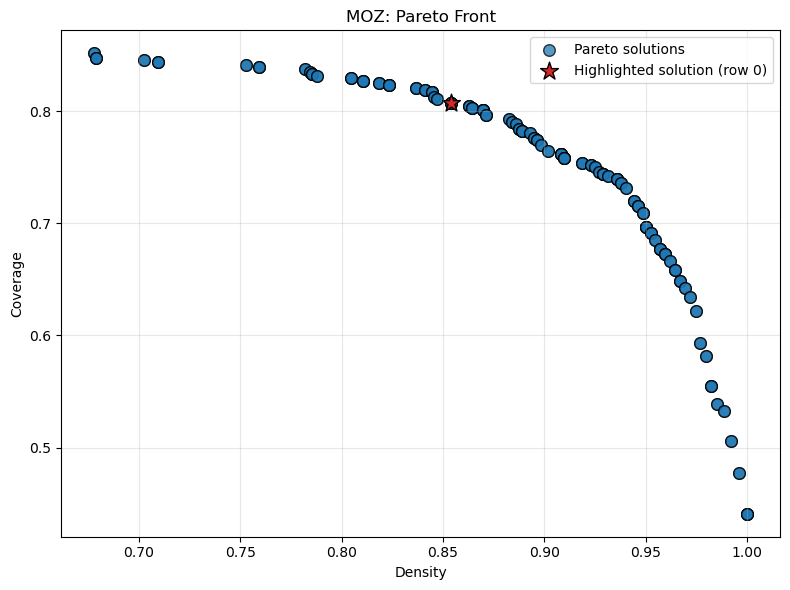

In [27]:
for region, opt_results_df in opt_results_df_dict.items():
    sdo.plot_pareto_front(
        opt_results_df["opt_result"],
        annotate=False,
        title=f"{region}: Pareto Front",
        save_path=os.path.join(FIGURES_DIR_PATH, f"{region.lower()}_pareto_front.png")
    )

### Optimized Boxes

KeyboardInterrupt: 

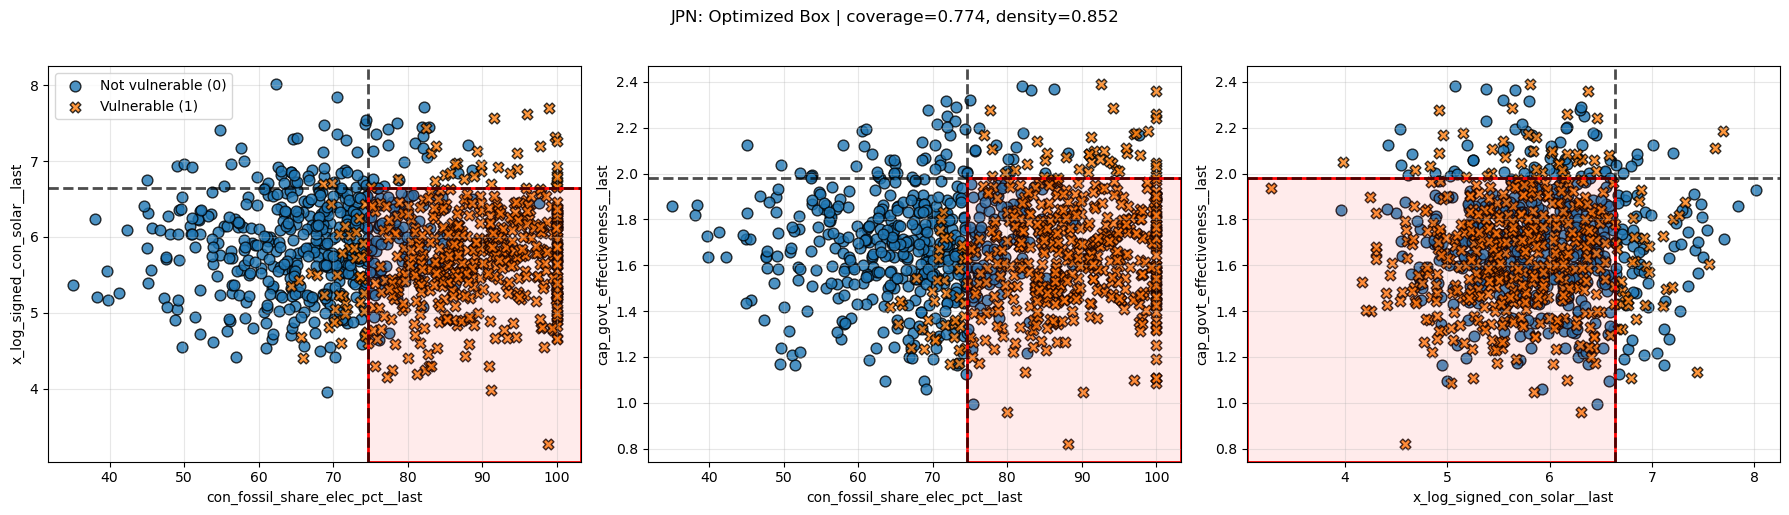

In [28]:
for region, opt_results_df in opt_results_df_dict.items():
    result_row = opt_results_df["opt_result"].iloc[0]

    sdo.plot_boxed_scatter_from_optimization_result(
        opt_results_df["opt_table_input"],
        opt_results_df["opt_result"],
        row_idx=0,
        title=(
            f"{region}: Optimized Box | "
            f"coverage={result_row['coverage']:.3f}, "
            f"density={result_row['density']:.3f}"
        ),
        save_path=os.path.join(FIGURES_DIR_PATH, f"{region.lower()}_optimized_box.png"),
    )


### Top driver combinations

In [ ]:
max_count = top_combinations_df['count'].max()
top_rows = top_combinations_df[top_combinations_df['count'] == max_count]

print("Top driver combination(s) and count:")
for _, row in top_rows.iterrows():
    print(f"{row['feature_combination']} — {int(row['count'])}")

Top driver combination(s) and count:
con_fossil_share_elec_pct|con_renewables_share_elec_pct|x_log_signed_con_primary_energy_twh — 30
